# Experiment Impact Analysis

This notebook evaluates the impact of the decision-support script tested in a call-centre field experiment.

The goal of the experiment was to improve customer outcomes when selecting broadband packages by simplifying decisions, building trust, and reducing decision regret.

We compare control and treatment groups using:
- customer satisfaction scores
- text feedback from post-call surveys
- temporal patterns in the experiment rollout

In [2]:
## Import Libraries

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_style("whitegrid")

In [3]:
## Load Processed Dataset
df = pd.read_csv("../data/processed/experiment_data_cleaned.csv")

df.shape


(647, 15)

In [4]:
df["VOLT_FLAG"].value_counts(dropna=False)

VOLT_FLAG
NaN    368
yes    279
Name: count, dtype: int64

## Create VOLT Segment Indicator

The column `VOLT_FLAG` marks customers belonging to the VOLT segment.
Missing values represent non-VOLT customers.

We convert this into a clean binary column for easier analysis.

In [5]:
df["volt_segment"] = df["VOLT_FLAG"].fillna("non_volt")

df["volt_segment"].value_counts()

volt_segment
non_volt    368
yes         279
Name: count, dtype: int64

In [6]:
df["volt_segment"] = df["volt_segment"].replace({"yes": "volt"})
df["volt_segment"].value_counts()

volt_segment
non_volt    368
volt        279
Name: count, dtype: int64

## Extract February Experiment Window

February is the only month where both control and treatment groups
appear simultaneously. We isolate this subset to perform a fair
comparison between the two scripts.

In [7]:
feb_df = df[df["month_name"] == "February"]

feb_df["experiment_group"].value_counts()

experiment_group
control      45
treatment    20
Name: count, dtype: int64

## Customer Score Comparison (February)

We compare customer satisfaction scores between the control
and treatment groups during the February experiment window.

In [8]:
feb_df.groupby("experiment_group")["SCORE"].describe()

,count,mean,std,min,25%,50%,75%,max
experiment_group,,,,,,,,
control,45.0,8.066667,3.193744,0.0,8.00,10.0,10.0,10.0
treatment,20.0,7.200000,3.707744,0.0,4.75,9.0,10.0,10.0


## Score Distribution by Experiment Group (February)

We visualize the score distribution for control and treatment groups
to better understand differences in customer satisfaction.

In [11]:
import os

os.makedirs("../outputs/figures", exist_ok=True)

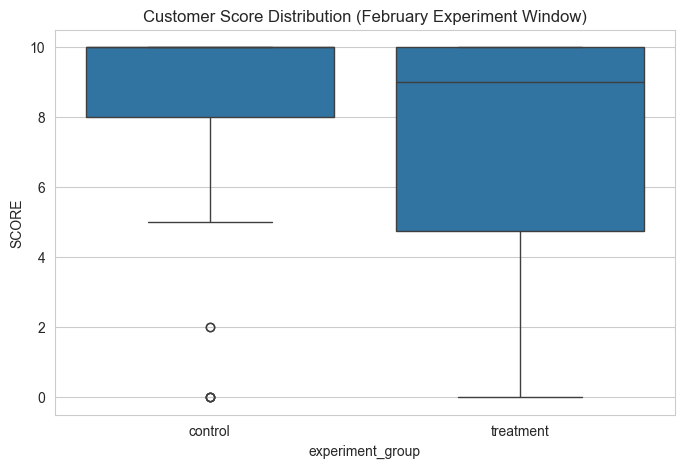

In [12]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=feb_df,
    x="experiment_group",
    y="SCORE"
)

plt.title("Customer Score Distribution (February Experiment Window)")

plt.savefig("../outputs/figures/score_distribution_february.png", dpi=300)

plt.show()

The treatment group does not show higher satisfaction scores compared to the control group during February.

In [14]:
from scipy.stats import ttest_ind

control_scores = feb_df[feb_df["experiment_group"] == "control"]["SCORE"]
treatment_scores = feb_df[feb_df["experiment_group"] == "treatment"]["SCORE"]

ttest_ind(control_scores, treatment_scores)

TtestResult(statistic=np.float64(0.9606335937330371), pvalue=np.float64(0.34040894849029707), df=np.float64(63.0))

| p-value  | Interpretation                |
| -------- | ----------------------------- |
| p < 0.05 | statistically significant     |
| p ≥ 0.05 | not statistically significant |


### T-test Result

An independent t-test was conducted to compare customer scores between control and treatment groups during the February experiment window.

The test returned:

- t statistic ≈ 0.96  
- p value ≈ 0.34

Since the p-value is greater than the significance threshold (0.05), the difference in customer scores between the two groups is **not statistically significant**.

This suggests that the new decision-support script did not produce a measurable improvement in customer satisfaction scores during the experiment period.

## Score Comparison by Customer Segment

The impact of the script may differ across customer segments.
We compare customer scores for VOLT and non-VOLT customers within the
February experiment window.

In [15]:
feb_df.groupby(["volt_segment", "experiment_group"])["SCORE"].describe()

count      mean       std  min   25%   50%  \
volt_segment experiment_group                                               
non_volt     control            14.0  8.285714  3.244607  0.0  8.25  10.0   
             treatment          13.0  7.846154  3.484397  0.0  8.00  10.0   
volt         control            31.0  7.967742  3.219564  0.0  7.50  10.0   
             treatment           7.0  6.000000  4.082483  0.0  3.00   8.0   

                                75%   max  
volt_segment experiment_group              
non_volt     control           10.0  10.0  
             treatment         10.0  10.0  
volt         control           10.0  10.0  
             treatment          9.0  10.0

The decision-support script may perform differently for VOLT customers compared to non-VOLT customers.

## Score Distribution by Segment and Experiment Group

We visualize how customer scores differ across both
experiment groups and customer segments.

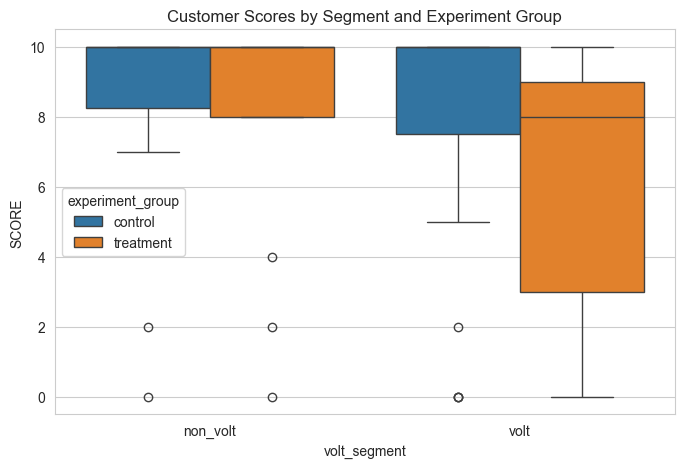

In [17]:
plt.figure(figsize=(8,5))

sns.boxplot(
    data=feb_df,
    x="volt_segment",
    y="SCORE",
    hue="experiment_group"
)

plt.title("Customer Scores by Segment and Experiment Group")

plt.savefig("../outputs/figures/segment_score_distribution.png", dpi=300)

plt.show()

### Segment-Level Insight

The experiment appears to have heterogeneous effects across customer segments.

For non-VOLT customers, satisfaction scores remain similar between control and treatment groups.

However, for VOLT customers, the treatment group shows noticeably lower scores and greater variability. This suggests that the decision-support script may not be well suited to the VOLT segment.

It is important to note that the treatment sample size for VOLT customers is small (n=7), so further data would be required to confirm this effect.